# Stage 2+3 — Frame extraction & ROI tracking (combined, Colab-first)

Two pipeline stages run in **one pass** so the full sampled-frame set never
leaves the Colab local disk and is never uploaded to Drive. Only the much
smaller ROI crops + per-video metadata are pushed back.

Per-video workflow:
1. `extract_frames.py` — shot detection, 2 fps sampling inside kept shots,
   lighting tag → `data/frames/{video}/frame_*.jpg` + `manifest.json`
2. `roi_track.py` — plume blob detection + temporal smoothing, crops →
   `data/frames/{video}/roi/frame_*.jpg`, boxes → `roi_boxes.json`
3. push `roi/*.jpg` + `manifest.json` + `roi_boxes.json` to Drive
4. delete the full sampled frames locally (frees space before the next video)

Only raw videos need to be on Drive beforehand (small uploads). Fully
resumable: a video whose `roi_boxes.json` already exists on Drive is skipped.

**Drive layout note:** this repo's local convention is `data/raw/{normal,anomaly}/*.mp4`,
but on Drive the videos were uploaded flat as `normal/` and `anomaly/` folders
directly under the project folder (no `data/raw/` nesting). Cell 3 below maps
between the two, so Drive doesn't need to be reorganized.


In [1]:
# --- Configuration (edit this cell for your environment) ---
import os, sys
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Drive project folder — the one that directly contains normal/ and
    # anomaly/ (NOT a path that already includes /normal or /data/raw).
    DRIVE_BASE = '/content/drive/MyDrive/Rocket Launch Anomaly Detection CV'
    LOCAL = '/content/rocket-launch-anomaly-detector'   # Colab local disk
else:
    # Local run: both point at the repo root (where this notebook lives).
    DRIVE_BASE = LOCAL = os.path.abspath('.')

FRAMES = Path(f'{LOCAL}/data/frames')   # local scratch + final roi/ output
print('IN_COLAB =', IN_COLAB)
print('DRIVE_BASE =', DRIVE_BASE)
print('FRAMES =', FRAMES)


IN_COLAB = True
DRIVE_BASE = /content/drive/MyDrive/Rocket Launch Anomaly Detection CV
FRAMES = /content/rocket-launch-anomaly-detector/data/frames


### 1. Environment setup

On Colab this clones the repo (if missing) and installs dependencies. On a
local checkout it just adds `scripts/` to the import path. `ffmpeg` is only
needed for AV1/VP9 webcasts that OpenCV can't decode; Colab has it.


In [2]:
# --- Cell: install deps + make scripts/ importable ---
import shutil
import time

if not os.path.exists(f'{LOCAL}/scripts/extract_frames.py'):
    # Repo is missing or stale. Either set GIT_URL to your repo, or upload the
    # project (scripts/ + requirements.txt) into LOCAL manually and re-run.
    GIT_URL = 'https://github.com/awdtyo/Rocket-Launch-Anomaly-Detection-using-CV'
    if os.path.isdir(LOCAL) and os.listdir(LOCAL):
        stale = f'{LOCAL}_stale_{int(time.time())}'
        shutil.move(LOCAL, stale)
        print(f'moved existing {LOCAL} -> {stale}')
    elif os.path.isdir(LOCAL):
        os.rmdir(LOCAL)   # empty dir left by a previously failed clone
    print('cloning repo ...')
    !git clone --depth 1 {GIT_URL} "{LOCAL}"
    if not os.path.exists(f'{LOCAL}/scripts/extract_frames.py'):
        raise RuntimeError('clone produced no scripts/ — set GIT_URL to your repo '
                           'or upload the project into LOCAL')

!pip install -q -r "{LOCAL}/requirements.txt"

sys.path.insert(0, f'{LOCAL}/scripts')
import extract_frames as EF
import roi_track as RT

print('imported extract_frames + roi_track')


cloning repo ...
Cloning into '/content/rocket-launch-anomaly-detector'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 49 (delta 13), reused 48 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 3.32 MiB | 24.10 MiB/s, done.
Resolving deltas: 100% (13/13), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 12.3 MB/s eta 0:00:00
imported extract_frames + roi_track


/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


### 2. Mount Drive + copy raw videos locally

Only the raw video files are copied from Drive — never any frame folders.
Frame extraction and ROI tracking then run entirely on the Colab local disk.

**Fix applied:** Drive has `normal/` and `anomaly/` directly under
`DRIVE_BASE` (no `data/raw/` nesting), so each label folder is copied
individually into the `data/raw/{label}/` layout the scripts expect locally.
The trailing `/.` on the source path copies the folder's *contents*, not the
folder itself, so we don't end up with a doubled-up `normal/normal/`.


In [3]:
# --- Cell: mount Drive, copy raw videos locally, define push/cleanup helpers ---
if IN_COLAB:
    drive.mount('/content/drive')

import shutil
from pathlib import Path

RAW_LOCAL = Path(f'{LOCAL}/data/raw')
DRIVE_FRAMES = Path(f'{DRIVE_BASE}/data/frames')

os.makedirs(str(RAW_LOCAL), exist_ok=True)
if os.path.isdir(RAW_LOCAL) and any(EF.iter_videos(RAW_LOCAL)):
    print('raw videos already on local disk:', RAW_LOCAL)
elif DRIVE_BASE != LOCAL:
    for label in ('normal', 'anomaly'):
        src = f'{DRIVE_BASE}/{label}'
        dst = f'{RAW_LOCAL}/{label}'
        if os.path.isdir(src):
            print(f'copying {label} from Drive ...')
            os.makedirs(dst, exist_ok=True)
            !cp -r "{src}/." "{dst}/"
        else:
            print(f'no {label}/ folder on Drive at {src} — skipping')
    print('copy done')
else:
    print('no raw videos found locally and DRIVE_BASE == LOCAL (nothing to copy)')


def push_video(name):
    """Push a finished video's ROI crops + metadata to Drive (small files only)."""
    if DRIVE_FRAMES == FRAMES:
        print('  local mode: outputs already at destination (nothing to push)')
        return
    vdir = Path(FRAMES) / name
    dst = Path(DRIVE_FRAMES) / name
    dst_roi = dst / 'roi'
    dst_roi.mkdir(parents=True, exist_ok=True)
    for fp in (vdir / 'roi').glob('frame_*.jpg'):
        shutil.copy2(fp, dst_roi / fp.name)
    for f in ('manifest.json', 'roi_boxes.json'):
        if (vdir / f).exists():
            shutil.copy2(vdir / f, dst / f)
    print('  pushed roi/ + manifest.json + roi_boxes.json for', name)


def free_local_frames(name):
    """Delete the full sampled frames (keep roi/, manifest, roi_boxes) to free space."""
    vdir = Path(FRAMES) / name
    n = 0
    for fp in vdir.glob('frame_*.jpg'):
        fp.unlink()
        n += 1
    print(f'  freed {n} full frames for {name} (kept roi/)')


Mounted at /content/drive
copying normal from Drive ...
no anomaly/ folder on Drive at /content/drive/MyDrive/Rocket Launch Anomaly Detection CV/anomaly — skipping
copy done


### 3. Extract → track → push ROI → free local space (resumable)

For each raw video: extract sampled frames, crop the ROI, push only the small
outputs (`roi/*.jpg`, `manifest.json`, `roi_boxes.json`) back to Drive, then
delete the full sampled frames from local disk. Videos whose `roi_boxes.json`
already exists on Drive are skipped. Test on one video first via `ONLY`.


In [4]:
# --- Cell: run extract → track → push → cleanup for every raw video (resumable) ---
import argparse

# Same defaults as scripts/extract_frames.py --help.
EF_ARGS = argparse.Namespace(fps=2.0, min_shot=2.0, threshold=27.0,
                             brightness_samples=24, night_threshold=45.0,
                             day_threshold=100.0, quality=95, progress=True)

# Test on one video first, then set back to None for the full batch.
ONLY = None   # e.g. 'spacex_starlink-20230303'

done = set()
if os.path.isdir(DRIVE_FRAMES):
    done = {d for d in os.listdir(DRIVE_FRAMES)
            if os.path.exists(f'{DRIVE_FRAMES}/{d}/roi_boxes.json')}
print('already on Drive:', sorted(done) or '(none)')

n_done = 0
for label, vpath in EF.iter_videos(RAW_LOCAL):
    name = vpath.stem
    if ONLY and ONLY not in name:
        continue
    if name in done:
        print(f'{name}: skipped (roi_boxes.json already on Drive)')
        continue

    vdir = Path(FRAMES) / name
    try:
        if not (vdir / 'roi_boxes.json').exists():
            print(f'extracting {label} {name} ...', flush=True)
            summary = EF.extract_video(label, vpath, FRAMES, EF_ARGS)
            if 'error' in summary:
                print(f'{name}: skipped ({summary["error"]})')
                continue
            print(f'  {summary["frames"]} frames, {summary["shots_kept"]} shots kept, '
                  f'lighting={summary["lighting"]}', flush=True)

            def progress(i, total):
                if i % 200 == 0 or i == total:
                    print(f'  roi {name}: {i}/{total} frames ...', end='\r')

            rsummary = RT.process_video(vdir, progress=progress)
            if 'error' in rsummary:
                print(f'{name}: skipped ({rsummary["error"]})')
                continue
            print(f'  {rsummary["boxes"]} crops, {rsummary["fallbacks"]} fallback frames', flush=True)
        else:
            print(f'{name}: roi already local — pushing + cleaning up only')

        push_video(name)
        free_local_frames(name)
        n_done += 1
        print('done:', name, flush=True)
    except Exception as exc:
        print(f'{name}: FAILED ({exc}) — will retry on the next run')

print(f'\n{n_done} videos processed.')


already on Drive: (none)
extracting normal spacex_sda-tranche-0-2 ...


INFO:pyscenedetect:Detecting scenes...


  2852 frames, 29 shots kept, lighting=day
  2852 crops, 5 fallback frames
  pushed roi/ + manifest.json + roi_boxes.json for spacex_sda-tranche-0-2
  freed 2852 full frames for spacex_sda-tranche-0-2 (kept roi/)
done: spacex_sda-tranche-0-2
extracting normal spacex_starlink-20230212 ...


INFO:pyscenedetect:Detecting scenes...


  2337 frames, 31 shots kept, lighting=night
  2337 crops, 153 fallback frames
  pushed roi/ + manifest.json + roi_boxes.json for spacex_starlink-20230212
  freed 2337 full frames for spacex_starlink-20230212 (kept roi/)
done: spacex_starlink-20230212
extracting normal spacex_starlink-20230303 ...


...

  2079 frames, 21 shots kept, lighting=night
  2079 crops, 3 fallback frames
  pushed roi/ + manifest.json + roi_boxes.json for spacex_starlink-20230822
  freed 2079 full frames for spacex_starlink-20230822 (kept roi/)
done: spacex_starlink-20230822
extracting normal spacex_starlink-20230827 ...


INFO:pyscenedetect:Detecting scenes...


  2000 frames, 28 shots kept, lighting=night
  2000 crops, 70 fallback frames
  pushed roi/ + manifest.json + roi_boxes.json for spacex_starlink-20230827
  freed 2000 full frames for spacex_starlink-20230827 (kept roi/)
done: spacex_starlink-20230827
extracting normal spacex_starlink-20230901 ...


INFO:pyscenedetect:Detecting scenes...


  1901 frames, 22 shots kept, lighting=night
  1901 crops, 2 fallback frames
  pushed roi/ + manifest.json + roi_boxes.json for spacex_starlink-20230901
  freed 1901 full frames for spacex_starlink-20230901 (kept roi/)
done: spacex_starlink-20230901

13 videos processed.


### 4. Sanity-check the pushed results on Drive

For every video with `roi_boxes.json` on Drive, confirms the `roi/` frame
count matches the number of recorded boxes and flags any mismatches.


In [7]:
# --- Cell: verify every video pushed to Drive matches its roi_boxes.json ---
import json
from pathlib import Path

DF = Path(DRIVE_FRAMES)
if not DF.is_dir():
    print('nothing on Drive yet — run the batch cell first.')
else:
    print(f'{"video":<32}{"roi_frames":>11}{"boxes":>7}{"fb":>5}{"lit":>6}  ok')
    print('-' * 70)
    n_ok = n_bad = 0
    for vdir in sorted(DF.iterdir()):
        boxes_path = vdir / 'roi_boxes.json'
        if not boxes_path.is_file():
            continue
        boxes = json.loads(boxes_path.read_text())
        n_roi = len([f for f in os.listdir(vdir / 'roi') if f.endswith('.jpg')])
        n_boxes = len(boxes.get('boxes', {}))
        n_fb = len(boxes.get('fallback_frames', []))
        lighting = boxes.get('video', {}).get('lighting', '?')
        ok = (n_roi == n_boxes) and n_boxes > 0
        n_ok += ok
        n_bad += (not ok)
        print(f'{vdir.name:<32}{n_roi:>11}{n_boxes:>7}{n_fb:>5}{lighting:>6}  {ok}')
    print(f'\n{n_ok} consistent, {n_bad} mismatches'
          + (' — ALL GOOD' if n_bad == 0 else ' — INVESTIGATE before continuing'))


video                            roi_frames  boxes   fb   lit  ok
----------------------------------------------------------------------
spacex_sda-tranche-0-2                 2852   2852    5   day  True
spacex_starlink-20230212               2337   2337  153 night  True
spacex_starlink-20230303               2725   2725  164  dusk  True
spacex_starlink-20230419               2214   2214  226  dusk  True
spacex_starlink-20230519               2470   2470   30 night  True
spacex_starlink-20230531               2216   2216   52 night  True
spacex_starlink-20230612               2217   2217   39 night  True
spacex_starlink-20230622               2116   2116    1  dusk  True
spacex_starlink-20230707               2202   2202    2  dusk  True
spacex_starlink-20230808               2268   2268   98 night  True
spacex_starlink-20230822               2079   2079    3 night  True
spacex_starlink-20230827               2000   2000   70 night  True
spacex_starlink-20230901               1901   1

### 5. Spot-check tracking quality

Same plume-mask view as the stage-4 notebook, but on a raw ROI crop, with the
`roi_track` plume box drawn on top — eyeball that the tracker is locking onto
the plume before trusting the batch output.


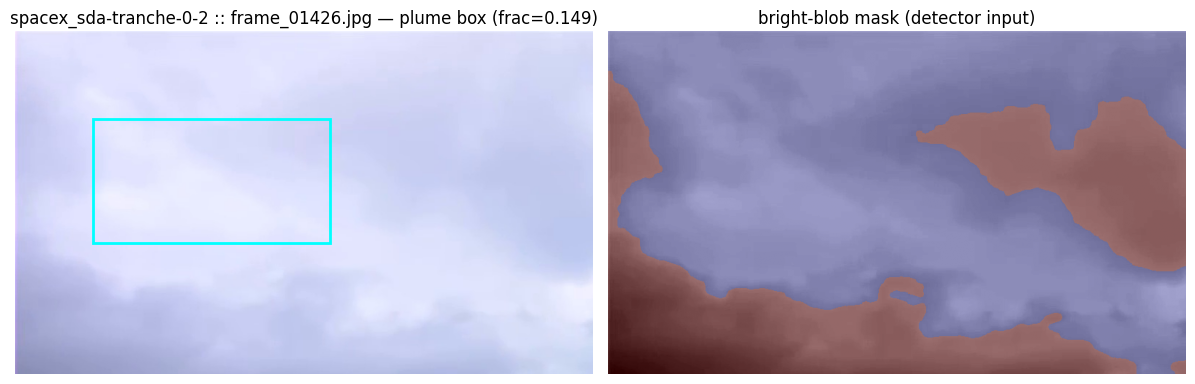

In [6]:
# --- Cell: eyeball tracking quality on a local ROI crop ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

roi_dirs = sorted(Path(FRAMES).glob('*/roi'))
if not roi_dirs:
    print('no local ROI crops yet — run the batch cell first.')
else:
    vdir = roi_dirs[0].parent
    crops = sorted((vdir / 'roi').glob('frame_*.jpg'))
    mid = crops[len(crops) // 2]
    frame = cv2.imread(str(mid))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Same bright-blob mask the roi_track detector uses.
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    bright = (blur >= otsu).astype(np.uint8) * 255
    if bright.mean() > 127:
        bright = (blur >= float(np.percentile(blur, 93))).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask = cv2.morphologyEx(cv2.morphologyEx(bright, cv2.MORPH_CLOSE, k), cv2.MORPH_OPEN, k)

    box, frac = RT.detect_plume(gray, None, motion_thresh=12, min_area_frac=0.002)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    if box is not None:
        x, y, bw, bh = box
        ax[0].add_patch(Rectangle((x, y), bw, bh, fill=False, ec='cyan', lw=2))
        ax[0].set_title(f'{vdir.name} :: {mid.name} — plume box (frac={frac:.3f})')
    else:
        ax[0].set_title(f'{vdir.name} :: {mid.name} — no plume (full-frame fallback)')
    ax[0].axis('off')
    ax[1].imshow(gray, cmap='gray')
    ax[1].imshow(mask, cmap='jet', alpha=0.35)
    ax[1].set_title('bright-blob mask (detector input)')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
